In [2]:
# Load in packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

In [3]:
# Function to get path

from pathlib import Path

def get_path(cell_line: str, path_file: str = "data_path.txt") -> str:
    """
    Reads a base directory path from a text file and returns the full path
    to the cell line data directory.

    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
        path_file (str): Path to the text file containing the base directory path.

    Returns:
        str: Full path to the data file for the given cell line.
    """
    # Read base path from file
    base_path = Path(path_file).read_text().strip()
    
    # Build full path
    full_path = Path(base_path) / f"{cell_line}_all-data.feather"
    
    return str(full_path)

In [4]:
# Read in HepG2 table
big_data_path = get_path("HepG2")
data = pl.read_ipc(big_data_path)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [15]:
# RBFOX2 Position 1 in HepG2 example

columns_to_keep = [
    "rMATS Event ID",
    "RBFOX2_1_binding",
    "FDR",
    "DeltaPSI",
    "RBFOX2_1_shap",
    "Sample Name"
]

# Drop unneccesary columns
rbfox2_data = data.select(columns_to_keep)

In [18]:
# Unique ID rows where RBFOX2 is bound @ 1

rbfox2_filtered = (
    rbfox2_data
    .filter(
        (pl.col("Sample Name").str.contains("KD", literal=True)) &
        (pl.col("RBFOX2_1_binding") == 1)
    )
    .unique(subset=["rMATS Event ID"])
)

# Convert to pandas
df = rbfox2_filtered.to_pandas()


In [19]:
print(df)

      rMATS Event ID  RBFOX2_1_binding       FDR  DeltaPSI  RBFOX2_1_shap  \
0              31479                 1  1.000000     0.016   1.952399e-05   
1              28225                 1  0.037636    -0.025   2.424824e-05   
2              17054                 1  1.000000     0.011   5.071412e-05   
3              13380                 1  1.000000    -0.008   2.019480e-03   
4              38050                 1  1.000000    -0.004   1.961021e-05   
...              ...               ...       ...       ...            ...   
8249           67084                 1  1.000000    -0.037   5.388809e-05   
8250           63142                 1  0.487096    -0.020  -6.325107e-06   
8251           21975                 1  1.000000    -0.002  -6.844992e-06   
8252           29624                 1  0.010734    -0.331   2.373729e-07   
8253            5079                 1  1.000000     0.009   5.505569e-05   

      Sample Name  
0       YBX3_KD-1  
1      PCBP1_KD-1  
2      NCBP2_KD

In [20]:
# Add a new column based on significance (significant if FDR <= 0.05 and abs dPSI >= 0.1

import numpy as np

df['Significant'] = np.where(
    (df['FDR'] <= 0.05) & (df['DeltaPSI'].abs() >= 0.1),
    1,
    0
)

In [21]:
print(df)

      rMATS Event ID  RBFOX2_1_binding       FDR  DeltaPSI  RBFOX2_1_shap  \
0              31479                 1  1.000000     0.016   1.952399e-05   
1              28225                 1  0.037636    -0.025   2.424824e-05   
2              17054                 1  1.000000     0.011   5.071412e-05   
3              13380                 1  1.000000    -0.008   2.019480e-03   
4              38050                 1  1.000000    -0.004   1.961021e-05   
...              ...               ...       ...       ...            ...   
8249           67084                 1  1.000000    -0.037   5.388809e-05   
8250           63142                 1  0.487096    -0.020  -6.325107e-06   
8251           21975                 1  1.000000    -0.002  -6.844992e-06   
8252           29624                 1  0.010734    -0.331   2.373729e-07   
8253            5079                 1  1.000000     0.009   5.505569e-05   

      Sample Name  Significant  
0       YBX3_KD-1            0  
1      PC

In [22]:
# Make training data

smaller_df = df[['RBFOX2_1_shap', 'Significant', 'rMATS Event ID']].copy()

smaller_df['absolute_shap'] = smaller_df['RBFOX2_1_shap'].abs()

smaller_df = smaller_df.rename(columns={'rMATS Event ID': 'Event_ID'})

smaller_df = smaller_df[['absolute_shap', 'Significant', 'Event_ID']]

In [23]:
print(smaller_df)

      absolute_shap  Significant  Event_ID
0      1.952399e-05            0     31479
1      2.424824e-05            0     28225
2      5.071412e-05            0     17054
3      2.019480e-03            0     13380
4      1.961021e-05            0     38050
...             ...          ...       ...
8249   5.388809e-05            0     67084
8250   6.325107e-06            0     63142
8251   6.844992e-06            0     21975
8252   2.373729e-07            1     29624
8253   5.505569e-05            0      5079

[8254 rows x 3 columns]


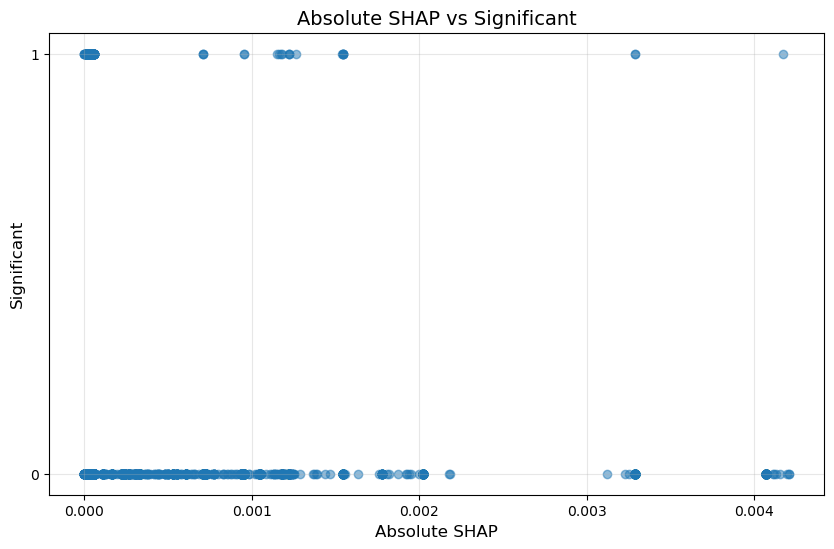

In [25]:
# Plot the data for one feature (RBFOX2 @ 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(smaller_df['absolute_shap'], smaller_df['Significant'], alpha=0.5)
plt.xlabel('Absolute SHAP', fontsize=12)
plt.ylabel('Significant', fontsize=12)
plt.title('Absolute SHAP vs Significant', fontsize=14)
plt.yticks([0, 1])
plt.grid(alpha=0.3)
plt.show()

In [29]:
# Training logistic regression model

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Prepare your data
X = smaller_df[['absolute_shap']].values  # Features (needs to be 2D array)
y = smaller_df['Significant'].values       # Target

# Train a classifier on all data
classifier = LogisticRegression()
classifier.fit(X, y)

# Get predicted probabilities for the same data
y_pred_proba = classifier.predict_proba(X)[:, 1]  # Probability of class 1

In [30]:
# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Calculate PRC
precision, recall, thresholds_pr = precision_recall_curve(y, y_pred_proba)
avg_precision = average_precision_score(y, y_pred_proba)

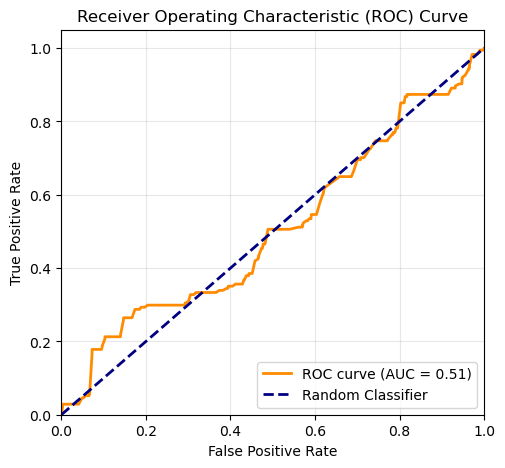

In [31]:
# Plot ROC Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

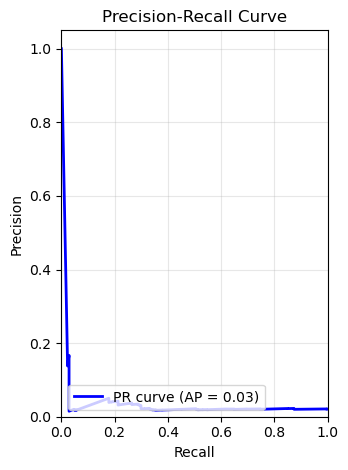

In [32]:
# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()